# Assignment 1 — Uncertainty and Sentiment Analysis of 10-K/10-Q Filings
FRE-GY 7871A, Fall 2026

This notebook follows `REPORT.md`'s section order (1–8) and produces Tables 1–6 and Figure 1
exactly as specified on the assignment sheet and in the starter repo README.

**Before running this notebook**, run, in order, from the repo root:
```
python scripts/00_get_lexicons.py
python scripts/01_build_universe.py
python scripts/02_download_filings.py --limit 3   # sanity check
python scripts/02_download_filings.py             # full run (~25 min)
python scripts/03_get_market_data.py
```

This notebook assumes the outputs described in the repo README:
- `data/lexicons/LoughranMcDonald_MasterDictionary.csv`
- `data/universe/universe.csv` (final SEC-filer universe) and a raw ARK holdings snapshot
- `data/interim/filings_meta.csv` — one row per filing: `ticker, cik, form, filing_date,
  report_date, acceptance_datetime, accession, n_words, n_distinct, text_path`
- `data/prices/` — daily prices, volume, VIX, and per-filing share counts (`shares.csv`)
- `src/edgar.py`, `src/parse.py`, `src/lexicons.py`, `src/market.py`, `src/config.py`

**A note on what this notebook can and can't guarantee**: the file/column layout below matches
the README exactly for `filings_meta.csv`, and matches the worked tf.idf example exactly (see
the self-check cell). The `data/prices/` file names are not pinned down in the README beyond
"daily prices, volume, VIX and per-filing share counts", so Section 0b below inspects what's
actually on disk and you may need to adjust the two or three constants flagged `# ADJUST ME`
if your `03_get_market_data.py` wrote different file/column names.

## 0a. Setup

In [1]:
import sys, os, gzip, glob, json, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 1000)

REPO_ROOT = Path(".").resolve()      # run this notebook from the repo root
DATA = REPO_ROOT / "data"
SRC = REPO_ROOT / "src"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Use the repo's own tokenizer / lexicon loader when available so our word
# counts agree with n_words/n_distinct already in filings_meta.csv and with
# everyone else's numbers. Fall back to a manual version only if src/ isn't
# importable (e.g. you're running this notebook from a different folder).
USE_REPO_MODULES = True
try:
    from src.parse import tokenize as repo_tokenize
    from src.lexicons import load_all as repo_load_all
except Exception as e:
    print("Could not import src.parse / src.lexicons:", e)
    print("Falling back to a manual tokenizer + manual lexicon loader.")
    USE_REPO_MODULES = False

print("Using repo tokenizer/lexicons:", USE_REPO_MODULES)


Using repo tokenizer/lexicons: True


## 0b. Inspect what's actually on disk

In [3]:
for sub in ["lexicons", "universe", "interim", "prices"]:
    p = DATA / sub
    print(f"--- data/{sub} ---")
    if not p.exists():
        print("  (missing)")
        continue
    for f in sorted(p.glob("*")):          # top level only -- interim/text/ has hundreds of files
        if f.is_dir():
            n = sum(1 for _ in f.glob("*"))
            print(f"  {f.name}/  ({n} files)")
        else:
            print(f"  {f.name}")

print()
meta_path = DATA / "interim" / "filings_meta.csv"
if meta_path.exists():
    _peek = pd.read_csv(meta_path, nrows=3)
    print("filings_meta.csv columns:", list(_peek.columns))

print()
for cand in ["prices.csv", "volume.csv", "shares.csv"]:
    p = DATA / "prices" / cand
    if not p.exists():
        continue
    _peek = pd.read_csv(p, nrows=3)
    print(f"--- {cand} --- shape peek, columns: {list(_peek.columns)}")
    print(_peek.to_string())
    print()


--- data/lexicons ---
  .gitkeep
  LoughranMcDonald_MasterDictionary.csv
--- data/universe ---
  ark_holdings_raw.csv
  universe.csv
--- data/interim ---
  .gitkeep
  filings_meta.csv
  text/  (1682 files)
--- data/prices ---
  .gitkeep
  prices.csv
  shares.csv
  volume.csv

filings_meta.csv columns: ['ticker', 'cik', 'company', 'sic', 'sic_desc', 'form', 'filing_date', 'report_date', 'acceptance_datetime', 'accession', 'doc_url', 'n_words', 'n_distinct', 'text_path']

--- prices.csv --- shape peek, columns: ['Date', 'ABNB', 'ABSI', 'ACHR', 'ADPT', 'AIR', 'AMD', 'AMZN', 'ARCT', 'ARKK', 'AUR', 'AVAV', 'AVGO', 'BEAM', 'BFLY', 'BMNR', 'BWXT', 'CAT', 'CDNA', 'CERS', 'CMPS', 'COIN', 'CRCL', 'CRSP', 'CRWD', 'CRWV', 'DASH', 'DDOG', 'DE', 'DKNG', 'FIG', 'FRNM', 'GH', 'GOOG', 'GOOGL', 'GRMN', 'GTLB', 'HEI', 'HON', 'HOOD', 'ICE', 'ILMN', 'INTU', 'IONS', 'IRDM', 'ISRG', 'JOBY', 'KDK', 'KTOS', 'LHX', 'LLY', 'LMT', 'LUNR', 'MASS', 'MELI', 'META', 'NET', 'NFLX', 'NRIX', 'NTLA', 'NTRA', 'NVDA', 'OKL

## 3. Word lists
Loads Fin-Neg (Negative) and Fin-Unc (Uncertainty) from the LM Master Dictionary.

In [4]:
if USE_REPO_MODULES:
    lists = repo_load_all()
    negative_words = set(w.upper() for w in lists["Negative"])
    uncertainty_words = set(w.upper() for w in lists["Uncertainty"])
else:
    lm_df = pd.read_csv(DATA / "lexicons" / "LoughranMcDonald_MasterDictionary.csv")
    negative_words = set(lm_df[lm_df['Negative'] != 0]['Word'].str.upper())
    uncertainty_words = set(lm_df[lm_df['Uncertainty'] != 0]['Word'].str.upper())

print(f"Negative (Fin-Neg) words:    {len(negative_words)}")
print(f"Uncertainty (Fin-Unc) words: {len(uncertainty_words)}")
overlap = negative_words & uncertainty_words
print(f"Overlap between the two lists: {len(overlap)} words "
      f"({100*len(overlap)/len(negative_words):.1f}% of Negative, "
      f"{100*len(overlap)/len(uncertainty_words):.1f}% of Uncertainty)")


Negative (Fin-Neg) words:    2355
Uncertainty (Fin-Unc) words: 297
Overlap between the two lists: 40 words (1.7% of Negative, 13.5% of Uncertainty)


## 2. Data construction — sample filters (Table 1)

Filters are applied **in the exact order the repo specifies**, so the waterfall is comparable
across the class:

1. Drop amendments (10-K/A, 10-Q/A) and anything that failed to parse.
2. At least 2,000 words for a 10-K, 1,000 for a 10-Q.
3. One filing per company per calendar quarter, keeping the earliest.
4. A usable day 0, and a price on day -1 of at least \$3.
5. At least 60 trading days of returns before day 0 and 60 after.

Universe-level attrition (124 ARK holdings -> ~93 SEC filers) is reported separately above the
filing-level waterfall, since it happens before any filing exists to count.

In [5]:
raw_holdings = pd.read_csv(DATA / "universe" / "ark_holdings_raw.csv")
final_universe = pd.read_csv(DATA / "universe" / "universe.csv")

raw_ticker_col = "ticker" if "ticker" in raw_holdings.columns else raw_holdings.columns[0]
final_ticker_col = "ticker" if "ticker" in final_universe.columns else final_universe.columns[0]

n_raw_firms = raw_holdings[raw_ticker_col].nunique()
n_final_firms = final_universe[final_ticker_col].nunique()

print(f"ARK holdings across all 6 ETFs: {n_raw_firms} firms")
print(f"Resolved to SEC 10-K/10-Q filers: {n_final_firms} firms")
print(f"Dropped (foreign private issuer / private / no 2021-2025 history): {n_raw_firms - n_final_firms}")


ARK holdings across all 6 ETFs: 130 firms
Resolved to SEC 10-K/10-Q filers: 117 firms
Dropped (foreign private issuer / private / no 2021-2025 history): 13


In [6]:
meta = pd.read_csv(DATA / "interim" / "filings_meta.csv",
                    parse_dates=["filing_date", "report_date", "acceptance_datetime"])

waterfall_rows = []
def log_stage(name, df):
    waterfall_rows.append({"Filter": name, "Filings remaining": len(df),
                            "Firms remaining": df["ticker"].nunique() if "ticker" in df.columns else np.nan})
    return df

log_stage("0. All downloaded filings (2021-2025, final universe)", meta)

# --- Filter 1: drop amendments and failed parses -----------------------------------------
df = meta[~meta["form"].astype(str).str.contains("/A", na=False)].copy()
df = df[df["n_words"].notna() & (df["n_words"] > 0)]
log_stage("1. Drop amendments (10-K/A, 10-Q/A) and failed parses", df)

# --- Filter 2: minimum word counts -------------------------------------------------------
is_10k = df["form"].astype(str).str.upper().str.startswith("10-K")
is_10q = df["form"].astype(str).str.upper().str.startswith("10-Q")
keep = (is_10k & (df["n_words"] >= 2000)) | (is_10q & (df["n_words"] >= 1000))
df = df[keep].copy()
log_stage("2. Min words (10-K >= 2,000, 10-Q >= 1,000)", df)

# --- Filter 3: one filing per firm per calendar quarter, keep earliest -------------------
df["quarter"] = df["filing_date"].dt.to_period("Q")
df = df.sort_values("filing_date").groupby(["ticker", "quarter"], as_index=False).first()
log_stage("3. One filing per firm per calendar quarter (earliest kept)", df)

print(pd.DataFrame(waterfall_rows))


                                              Filter  Filings remaining  Firms remaining
0  0. All downloaded filings (2021-2025, final un...               1702               93
1  1. Drop amendments (10-K/A, 10-Q/A) and failed...               1702               93
2        2. Min words (10-K >= 2,000, 10-Q >= 1,000)               1702               93
3  3. One filing per firm per calendar quarter (e...               1688               93


### Day 0 and the price/volatility filters

Day 0 is the first trading day on or after the later of (a) the EDGAR filing date and
(b) the acceptance date, shifted forward one day if acceptance lands at/after 16:00 Eastern.
`acceptance_datetime` is UTC in `filings_meta.csv`, so we convert to US/Eastern first.

The trading calendar is taken from the set of dates for which we have SPY (or another
benchmark) prices in `data/prices/`, since that's the calendar the rest of the analysis
has to live on anyway.

In [7]:
# ADJUST ME only if the auto-detection below prints a warning that it could
# not find something -- then tell me what the printed columns/tickers were.
SHARES_FILE = DATA / "prices" / "shares.csv"
BENCHMARK_TICKER = "SPY"

def find_col(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

def load_panel_long(path, value_name):
    """Load a price/volume file that is either:
       (a) 'wide': first column is date, every other column is a ticker, or
       (b) 'long': explicit date/ticker/value columns.
       Returns a long dataframe with columns [date, ticker, value_name]."""
    raw = pd.read_csv(path)
    raw.columns = [str(c).strip() for c in raw.columns]

    ticker_col = find_col(raw, ["ticker", "symbol"])
    date_col = find_col(raw, ["date", "trade_date", "trading_date"])

    if ticker_col is not None and date_col is not None:
        # already long -- find the value column (whatever isn't date/ticker)
        val_col = find_col(raw, [value_name, "close", "adj_close", "adjclose",
                                  "price", "volume", "vol"])
        if val_col is None:
            other = [c for c in raw.columns if c not in (date_col, ticker_col)]
            assert len(other) == 1, f"Ambiguous value column in {path.name}: {other}"
            val_col = other[0]
        out = raw.rename(columns={date_col: "date", ticker_col: "ticker", val_col: value_name})
        out = out[["date", "ticker", value_name]]
    else:
        # assume wide: first column is date, remaining columns are tickers
        first_col = raw.columns[0]
        raw = raw.rename(columns={first_col: "date"})
        out = raw.melt(id_vars="date", var_name="ticker", value_name=value_name)

    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out = out.dropna(subset=["date", value_name])
    return out

price_long = load_panel_long(DATA / "prices" / "prices.csv", "price")
volume_long = load_panel_long(DATA / "prices" / "volume.csv", "volume")

prices = price_long.merge(volume_long, on=["date", "ticker"], how="left")
price_col = "price"

tickers_seen = sorted(prices["ticker"].astype(str).unique())
print(f"Loaded prices: {len(prices)} rows, {len(tickers_seen)} tickers.")
print("Sample tickers:", tickers_seen[:15])

if BENCHMARK_TICKER not in tickers_seen:
    print(f"WARNING: benchmark ticker '{BENCHMARK_TICKER}' not found. "
          f"Set BENCHMARK_TICKER to one of the tickers printed above.")

# There is no separate vix.csv in this data pull, so look for VIX as a ticker
# inside prices.csv (common when a market-data script just adds it to the
# same download list).
vix_like = [t for t in tickers_seen if str(t).upper().replace("^", "").replace("-", "") == "VIX"]
if vix_like:
    vix_ticker = vix_like[0]
    vix = prices.loc[prices["ticker"] == vix_ticker, ["date", "price"]].rename(columns={"price": "vix"})
    vix_col = "vix"
    print(f"Found VIX as ticker '{vix_ticker}' inside prices.csv.")
else:
    vix = None
    print("WARNING: no VIX-like ticker found in prices.csv or as a separate file.")
    print("Figure 1 will be drawn without the VIX overlay until you tell me where VIX actually lives.")
    print("All tickers found:", tickers_seen)

shares_raw = pd.read_csv(SHARES_FILE) if SHARES_FILE.exists() else None
if shares_raw is not None:
    shares_raw.columns = [str(c).strip() for c in shares_raw.columns]
    print("\nshares.csv columns:", list(shares_raw.columns))

trading_days = pd.DatetimeIndex(sorted(prices.loc[prices["ticker"] == BENCHMARK_TICKER, "date"].unique()))
print(f"\nTrading calendar spans {trading_days.min().date()} to {trading_days.max().date()} "
      f"({len(trading_days)} trading days)")


Loaded prices: 122119 rows, 96 tickers.
Sample tickers: ['ABNB', 'ABSI', 'ACHR', 'ADPT', 'AIR', 'AMD', 'AMZN', 'ARCT', 'ARKK', 'AUR', 'AVAV', 'AVGO', 'BEAM', 'BFLY', 'BMNR']
Found VIX as ticker '^VIX' inside prices.csv.

shares.csv columns: ['cik', 'accession', 'shares_outstanding', 'shares_as_of', 'shares_tag']

Trading calendar spans 2020-09-01 to 2026-03-30 (1400 trading days)


In [8]:
import pytz

def to_day0(filing_date, acceptance_dt):
    """First trading day on/after the later of filing_date and the (possibly +1 day)
    acceptance date, per the repo's day-0 rule."""
    base = pd.Timestamp(filing_date).normalize()
    if pd.notna(acceptance_dt):
        acc_utc = pd.Timestamp(acceptance_dt)
        if acc_utc.tzinfo is None:
            acc_utc = acc_utc.tz_localize("UTC")
        acc_et = acc_utc.tz_convert("US/Eastern")
        acc_date = acc_et.normalize().tz_localize(None)
        if acc_et.hour >= 16:
            acc_date = acc_date + pd.Timedelta(days=1)
        base = max(base, acc_date)
    idx = trading_days.searchsorted(base)
    if idx >= len(trading_days):
        return pd.NaT
    return trading_days[idx]

df["day0"] = df.apply(lambda r: to_day0(r["filing_date"], r["acceptance_datetime"]), axis=1)
moved = (df["day0"].dt.normalize() != df["filing_date"].dt.normalize()).sum()
print(f"Day-0 differs from the raw EDGAR filing date for {moved} of {len(df)} filings "
      f"({100*moved/len(df):.1f}%).")

def trading_offset(date0, offset):
    idx = trading_days.searchsorted(date0)
    j = idx + offset
    if j < 0 or j >= len(trading_days):
        return pd.NaT
    return trading_days[j]

df["day_m1"]  = df["day0"].apply(lambda d: trading_offset(d, -1) if pd.notna(d) else pd.NaT)
df["day_p3"]  = df["day0"].apply(lambda d: trading_offset(d, 3)  if pd.notna(d) else pd.NaT)


Day-0 differs from the raw EDGAR filing date for 948 of 1688 filings (56.2%).


In [9]:
def get_price(ticker, date):
    if pd.isna(date):
        return np.nan
    row = prices[(prices["ticker"] == ticker) & (prices["date"] == date)] if "ticker" in prices.columns else prices[prices["date"] == date]
    return row[price_col].iloc[0] if len(row) else np.nan

df["price_m1"] = df.apply(lambda r: get_price(r["ticker"], r["day_m1"]), axis=1)

# Filter 4: usable day 0 and price on day -1 >= $3
df = df[df["day0"].notna() & df["day_m1"].notna() & (df["price_m1"] >= 3)].copy()
log_stage("4. Usable day 0 and price[-1] >= $3", df)

# Filter 5: >= 60 trading days of returns before day 0 and 60 after
def has_60_before_after(d0):
    idx = trading_days.searchsorted(d0)
    return (idx - 60 >= 0) and (idx + 60 < len(trading_days))
df = df[df["day0"].apply(has_60_before_after)].copy()
log_stage("5. >= 60 trading days before and after day 0", df)

table_1 = pd.DataFrame(waterfall_rows)
table_1["Removed"] = table_1["Filings remaining"].diff().fillna(0).abs().astype(int)
print("TABLE 1 -- sample filtering waterfall")
display(table_1)


TABLE 1 -- sample filtering waterfall


,Filter,Filings remaining,Firms remaining,Removed
0,"0. All downloaded filings (2021-2025, final un...",1702,93,0
1,"1. Drop amendments (10-K/A, 10-Q/A) and failed...",1702,93,0
2,"2. Min words (10-K >= 2,000, 10-Q >= 1,000)",1702,93,0
3,3. One filing per firm per calendar quarter (e...,1688,93,14
4,4. Usable day 0 and price[-1] >= $3,1585,93,103
5,5. >= 60 trading days before and after day 0,1585,93,0


## Tokenize and score every surviving filing
tf.idf `N` and `df_i` are computed **on this final sample only** (not on every filing ever
downloaded), per the repo's warning about mixing corpora.

In [10]:
def load_tokens(text_path):
    opener = gzip.open if str(text_path).endswith(".gz") else open
    with opener(text_path, "rt", encoding="utf-8", errors="ignore") as fh:
        text = fh.read()
    if USE_REPO_MODULES:
        return repo_tokenize(text)
    # fallback tokenizer if src.parse isn't importable
    import re
    clean = re.sub(r"<[^>]+>", " ", text)
    return re.findall(r"\b[A-Za-z]{2,}\b", clean.upper())

records = []
top_neg_counter, top_unc_counter = Counter(), Counter()

for _, row in df.iterrows():
    try:
        tokens = [t.upper() for t in load_tokens(row["text_path"])]
    except Exception as e:
        continue
    total_words = len(tokens)
    distinct_words = len(set(tokens))
    if total_words == 0 or distinct_words == 0:
        continue
    t_counts = Counter(tokens)
    neg_count = sum(t_counts[w] for w in negative_words if w in t_counts)
    unc_count = sum(t_counts[w] for w in uncertainty_words if w in t_counts)
    for w in negative_words:
        if w in t_counts: top_neg_counter[w] += t_counts[w]
    for w in uncertainty_words:
        if w in t_counts: top_unc_counter[w] += t_counts[w]
    records.append({
        **row.to_dict(),
        "total_words": total_words, "distinct_words": distinct_words,
        "neg_count": neg_count, "unc_count": unc_count,
        "term_counts": t_counts,
    })

filing_df = pd.DataFrame(records)
print(f"Scored {len(filing_df)} filings.")


Scored 1585 filings.


In [11]:
N = len(filing_df)
doc_freq = Counter()
for counts in filing_df["term_counts"]:
    doc_freq.update(counts.keys())

filing_df["sentiment_share"]    = filing_df["neg_count"] / filing_df["total_words"]
filing_df["uncertainty_share"]  = filing_df["unc_count"] / filing_df["total_words"]

# a_j = total tokens in doc j / DISTINCT token types in doc j  (confirmed against the
# repo's 3-document worked example below -- do not swap this for total_words alone).
filing_df["a_j"] = filing_df["total_words"] / filing_df["distinct_words"]

def lm_tfidf(term_counts, a_j, target_vocab, N, doc_freq):
    score = 0.0
    for w in target_vocab:
        tf = term_counts.get(w, 0)
        if tf > 0:
            dfi = doc_freq.get(w, 1)
            idf = np.log(N / dfi)
            tf_weight = (1 + np.log(tf)) / (1 + np.log(a_j))
            score += tf_weight * idf
    return score

filing_df["sentiment_tfidf"] = filing_df.apply(
    lambda r: lm_tfidf(r["term_counts"], r["a_j"], negative_words, N, doc_freq), axis=1)
filing_df["uncertainty_tfidf"] = filing_df.apply(
    lambda r: lm_tfidf(r["term_counts"], r["a_j"], uncertainty_words, N, doc_freq), axis=1)


### tf.idf self-check
Reproduces the exact 3-document example from the starter repo README. If these three numbers
don't come out to 0.8480 / 0.2885 / 0.5026, something in the formula above is wrong — fix this
before trusting anything downstream.

In [12]:
toy_docs = {
    "d1": "LOSS LOSS RISK GAIN".split(),
    "d2": "LOSS GAIN GAIN".split(),
    "d3": "RISK RISK RISK GAIN".split(),
}
toy_vocab = {"LOSS", "RISK"}
toy_N = len(toy_docs)
toy_doc_freq = Counter()
for toks in toy_docs.values():
    toy_doc_freq.update(set(toks))

for name, toks in toy_docs.items():
    tc = Counter(toks)
    a_j = len(toks) / len(set(toks))
    prop = sum(tc[w] for w in toy_vocab) / len(toks)
    tfidf = lm_tfidf(tc, a_j, toy_vocab, toy_N, toy_doc_freq)
    print(f"{name}: a_j={a_j:.4f}  proportional={prop:.4f}  tf.idf={tfidf:.4f}")
print("\nExpected: d1 -> 0.7500 / 0.8480 | d2 -> 0.3333 / 0.2885 | d3 -> 0.7500 / 0.5026")


d1: a_j=1.3333  proportional=0.7500  tf.idf=0.8480
d2: a_j=1.5000  proportional=0.3333  tf.idf=0.2885
d3: a_j=2.0000  proportional=0.7500  tf.idf=0.5026

Expected: d1 -> 0.7500 / 0.8480 | d2 -> 0.3333 / 0.2885 | d3 -> 0.7500 / 0.5026


## 5. What the measures are made of — Table 2, Table 3, Q1, Q2

In [13]:
metrics = ["sentiment_share", "uncertainty_share", "sentiment_tfidf", "uncertainty_tfidf"]
table_2 = filing_df.groupby("form")[metrics].describe().T
print("TABLE 2 -- summary statistics, 10-K vs 10-Q")
display(table_2)


TABLE 2 -- summary statistics, 10-K vs 10-Q


form                           10-K         10-Q
sentiment_share   count  393.000000  1192.000000
                  mean     0.025471     0.021635
                  std      0.004480     0.010844
                  min      0.012768     0.003654
                  25%      0.022610     0.012070
                  50%      0.025766     0.017599
                  75%      0.028640     0.033158
                  max      0.036260     0.050438
uncertainty_share count  393.000000  1192.000000
                  mean     0.021115     0.019301
                  std      0.002607     0.006645
                  min      0.014154     0.006303
                  25%      0.019407     0.013790
                  50%      0.021310     0.017584
                  75%      0.022942     0.026096
                  max      0.027948     0.035802
sentiment_tfidf   count  393.000000  1192.000000
                  mean   166.927769    76.147882
                  std     61.102109    73.464802
                  min     59.725459     2.155887
                  25%    119.203410    16.187439
                  50%    151.671143    34.041959
                  75%    205.451090   135.767524
                  max    346.282993   284.671878
uncertainty_tfidf count  393.000000  1192.000000
                  mean    27.558102    12.755220
                  std      9.650453     8.748838
                  min     10.339559     1.344526
                  25%     20.406117     5.495072
                  50%     25.972422     9.854007
                  75%     32.328737    19.390135
                  max     64.278145    40.845309

In [14]:
total_neg = sum(top_neg_counter.values())
total_unc = sum(top_unc_counter.values())

top30_neg = pd.DataFrame(top_neg_counter.most_common(30), columns=["Negative Word", "Count"])
top30_neg["Share of Neg (%)"] = 100 * top30_neg["Count"] / total_neg

top30_unc = pd.DataFrame(top_unc_counter.most_common(30), columns=["Uncertainty Word", "Count"])
top30_unc["Share of Unc (%)"] = 100 * top30_unc["Count"] / total_unc

table_3 = pd.concat([top30_neg, top30_unc], axis=1)
print("TABLE 3 -- 30 most common words on each list")
display(table_3)

# Q1: concentration -- share of each list's count from its 10 most frequent words
print(f"\nTop-10 negative words carry {top30_neg['Share of Neg (%)'].head(10).sum():.1f}% of the Negative count")
print(f"Top-10 uncertainty words carry {top30_unc['Share of Unc (%)'].head(10).sum():.1f}% of the Uncertainty count")


TABLE 3 -- 30 most common words on each list


,Negative Word,Count,Share of Neg (%),Uncertainty Word,Count,Share of Unc (%)
0,LOSS,59512,4.752113,MAY,385473,37.472987
1,ADVERSELY,58926,4.705321,COULD,212485,20.656304
2,ADVERSE,36187,2.889581,RISK,51640,5.020079
3,CLAIMS,34015,2.716144,RISKS,51186,4.975945
4,HARM,27141,2.167245,BELIEVE,32112,3.121704
5,AGAINST,26790,2.139218,APPROXIMATELY,18537,1.802037
6,UNABLE,26715,2.133229,ASSUMPTIONS,13420,1.304598
7,FAILURE,25372,2.025988,FLUCTUATIONS,13274,1.290405
8,LOSSES,24571,1.962027,MIGHT,12705,1.235091
9,LITIGATION,23714,1.893595,UNCERTAINTIES,12648,1.229550



Top-10 negative words carry 27.4% of the Negative count
Top-10 uncertainty words carry 78.1% of the Uncertainty count


In [15]:
# Q2: are sentiment and uncertainty measuring different things?
corr_prop = filing_df[["sentiment_share", "uncertainty_share"]].corr().iloc[0, 1]
corr_tfidf = filing_df[["sentiment_tfidf", "uncertainty_tfidf"]].corr().iloc[0, 1]
print(f"Correlation (proportional): {corr_prop:.3f}")
print(f"Correlation (tf.idf):       {corr_tfidf:.3f}")

# find a filing that's high on one, low on the other
filing_df["senti_rank"] = filing_df["sentiment_share"].rank(pct=True)
filing_df["unc_rank"]   = filing_df["uncertainty_share"].rank(pct=True)
filing_df["divergence"] = (filing_df["senti_rank"] - filing_df["unc_rank"]).abs()
divergent_example = filing_df.sort_values("divergence", ascending=False).head(5)
cols = [c for c in ["ticker","form","filing_date","sentiment_share","uncertainty_share"] if c in filing_df.columns]
display(divergent_example[cols])


Correlation (proportional): 0.889
Correlation (tf.idf):       0.935


,ticker,form,filing_date,sentiment_share,uncertainty_share
435,DKNG,10-Q,2022-08-05,0.039694,0.015942
444,DKNG,10-Q,2024-11-08,0.050438,0.016389
436,DKNG,10-Q,2022-11-04,0.043156,0.016410
224,BMNR,10-Q,2025-07-02,0.009016,0.023601
443,DKNG,10-Q,2024-08-02,0.047200,0.017295


## 6. Trends, 2021-2025 — Figure 1 and Table 4

**Composition corrections applied before describing any trend** (per the assignment's "three
things to watch"):
- 10-Ks and 10-Qs are analyzed separately (10-Ks are longer, heavier in risk language, and
  cluster in Q1 — pooling would show a calendar sawtooth, not a real trend).
- The within-firm version demeans each series by firm before regressing on time, since firms
  differ enormously in baseline tone and which quarter they file in.

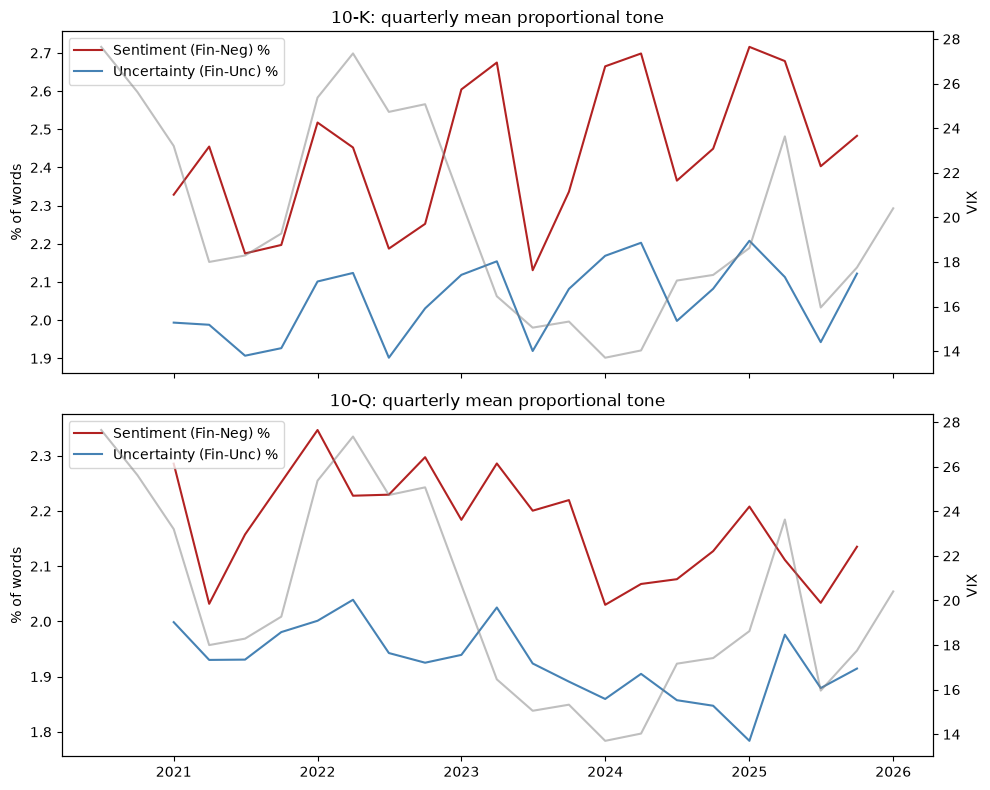

FIGURE 1 saved to figure1_tone_by_quarter.png


In [16]:
filing_df["quarter"] = pd.PeriodIndex(filing_df["filing_date"], freq="Q")
filing_df["t"] = (filing_df["quarter"] - filing_df["quarter"].min()).apply(lambda p: p.n)

quarterly = (filing_df.groupby(["quarter", "form"])[metrics]
             .mean().reset_index())
quarterly["quarter_ts"] = quarterly["quarter"].dt.to_timestamp()

if vix is not None:
    vix["quarter"] = pd.PeriodIndex(vix["date"], freq="Q")
    vix_q = vix.groupby("quarter")[vix_col].mean().reset_index()
    vix_q["quarter_ts"] = vix_q["quarter"].dt.to_timestamp()
else:
    vix_q = None

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for form, ax in zip(["10-K", "10-Q"], axes):
    sub = quarterly[quarterly["form"] == form]
    ax.plot(sub["quarter_ts"], sub["sentiment_share"]*100, label="Sentiment (Fin-Neg) %", color="firebrick")
    ax.plot(sub["quarter_ts"], sub["uncertainty_share"]*100, label="Uncertainty (Fin-Unc) %", color="steelblue")
    ax.set_title(f"{form}: quarterly mean proportional tone")
    ax.set_ylabel("% of words")
    ax.legend(loc="upper left")
    if vix_q is not None:
        ax2 = ax.twinx()
        ax2.plot(vix_q["quarter_ts"], vix_q[vix_col], color="gray", alpha=0.5, label="VIX")
        ax2.set_ylabel("VIX")
plt.xlabel("Quarter")
plt.tight_layout()
plt.savefig("figure1_tone_by_quarter.png", dpi=150)
plt.show()
print('FIGURE 1 saved to figure1_tone_by_quarter.png')


In [17]:
from statsmodels.stats.sandwich_covariance import cov_hac

def trend_test_aggregate(sub_df, y_col):
    q_means = sub_df.groupby("quarter")[y_col].mean().reset_index()
    q_means["t"] = np.arange(len(q_means))
    X = sm.add_constant(q_means["t"])
    ols = sm.OLS(q_means[y_col], X).fit()
    nw  = sm.OLS(q_means[y_col], X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
    return ols, nw, q_means

def trend_test_within_firm(sub_df, y_col):
    tmp = sub_df.copy()
    tmp["y_demeaned"] = tmp[y_col] - tmp.groupby("ticker")[y_col].transform("mean")
    X = sm.add_constant(tmp["t"])
    fit = sm.OLS(tmp["y_demeaned"], X).fit(
        cov_type="cluster", cov_kwds={"groups": tmp["ticker"]})
    return fit

table_4_rows = []
for form in ["10-K", "10-Q"]:
    sub = filing_df[filing_df["form"] == form]
    for measure in ["sentiment_share", "uncertainty_share"]:
        ols, nw, _ = trend_test_aggregate(sub, measure)
        wf = trend_test_within_firm(sub, measure)
        table_4_rows.append({
            "Form": form, "Measure": measure,
            "Aggregate slope (pp/yr)": ols.params["t"] * 4 * 100,
            "Aggregate t (OLS)": ols.tvalues["t"],
            "Aggregate t (Newey-West)": nw.tvalues["t"],
            "Within-firm slope (pp/yr)": wf.params["t"] * 4 * 100,
            "Within-firm t (clustered)": wf.tvalues["t"],
        })
table_4 = pd.DataFrame(table_4_rows)
print("TABLE 4 -- trend tests, aggregate and within-firm")
display(table_4)


TABLE 4 -- trend tests, aggregate and within-firm


,Form,Measure,Aggregate slope (pp/yr),Aggregate t (OLS),Aggregate t (Newey-West),Within-firm slope (pp/yr),Within-firm t (clustered)
0,10-K,sentiment_share,0.057492,2.105885,4.724745,0.076226,9.738099
1,10-K,uncertainty_share,0.028642,1.963343,3.054911,0.036306,6.947536
2,10-Q,sentiment_share,-0.031010,-2.304773,-2.655310,-0.034307,-2.011154
3,10-Q,uncertainty_share,-0.025607,-3.077029,-3.680587,-0.025074,-2.562094


## 7. Uncertainty, volatility and returns — Table 5, Table 6

Controls, per the repo spec: log size, log dollar volume and excess return over [-60,-6],
pre-filing volatility, a 10-K dummy, and firm and quarter fixed effects.

Windows: excess return over [0,+3] vs SPY from the close on day -1; realized volatility over
[-60,-6] before and [+4,+63] after, annualized.

In [18]:
def build_return_series(ticker, d0, lo, hi):
    """Daily simple returns for `ticker` on trading-day offsets [lo, hi] relative to d0."""
    idx = trading_days.searchsorted(d0)
    lo_i, hi_i = idx + lo, idx + hi
    if lo_i < 0 or hi_i >= len(trading_days):
        return None
    dates = trading_days[lo_i-1:hi_i+1]
    sub = prices[(prices["ticker"] == ticker) & (prices["date"].isin(dates))].sort_values("date")
    if len(sub) < (hi - lo + 1):
        return None
    px = sub.set_index("date")[price_col]
    return px.pct_change().dropna()

def build_bench_series(d0, lo, hi):
    idx = trading_days.searchsorted(d0)
    lo_i, hi_i = idx + lo, idx + hi
    dates = trading_days[lo_i-1:hi_i+1]
    sub = prices[(prices["ticker"] == BENCHMARK_TICKER) & (prices["date"].isin(dates))].sort_values("date")
    px = sub.set_index("date")[price_col]
    return px.pct_change().dropna()

def excess_holding_return(ticker, d0, lo, hi):
    r = build_return_series(ticker, d0, lo, hi)
    b = build_bench_series(d0, lo, hi)
    if r is None or len(r) == 0 or len(b) == 0:
        return np.nan
    return (1 + r).prod() - (1 + b.reindex(r.index).fillna(0)).prod()

def realized_vol(ticker, d0, lo, hi):
    r = build_return_series(ticker, d0, lo, hi)
    if r is None or len(r) < 5:
        return np.nan
    return r.std() * np.sqrt(252)

filing_df["excess_ret_0_3"]  = filing_df.apply(lambda r: excess_holding_return(r["ticker"], r["day0"], 0, 3), axis=1)
filing_df["excess_ret_m60_m6"] = filing_df.apply(lambda r: excess_holding_return(r["ticker"], r["day0"], -60, -6), axis=1)
filing_df["vol_pre"]  = filing_df.apply(lambda r: realized_vol(r["ticker"], r["day0"], -60, -6), axis=1)
filing_df["vol_post"] = filing_df.apply(lambda r: realized_vol(r["ticker"], r["day0"], 4, 63), axis=1)

def dollar_volume(ticker, d0, lo, hi):
    idx = trading_days.searchsorted(d0)
    dates = trading_days[idx+lo: idx+hi+1]
    sub = prices[(prices["ticker"] == ticker) & (prices["date"].isin(dates))]
    if "volume" not in sub.columns or len(sub) == 0:
        return np.nan
    return (sub[price_col] * sub["volume"]).mean()

filing_df["dollar_vol_pre"] = filing_df.apply(lambda r: dollar_volume(r["ticker"], r["day0"], -60, -6), axis=1)

# Merge in shares outstanding. We don't know a priori whether shares.csv is
# keyed by accession (one row per filing) or by ticker + a date (a time
# series of share counts) -- handle both, and normalize accession formatting
# (dashes are sometimes stripped between filings_meta.csv and other files).
def norm_accession(x):
    return str(x).replace("-", "").strip()

filing_df["size"] = np.nan
if shares_raw is not None:
    accession_col = find_col(shares_raw, ["accession", "accession_number"])
    share_col = find_col(shares_raw, ["shares_outstanding", "shares", "shares_out", "sharesoutstanding"])

    if accession_col is not None and share_col is not None and "accession" in filing_df.columns:
        s = shares_raw[[accession_col, share_col]].rename(
            columns={accession_col: "accession", share_col: "shares_outstanding"})
        s["_acc_key"] = s["accession"].map(norm_accession)
        filing_df["_acc_key"] = filing_df["accession"].map(norm_accession)
        filing_df = filing_df.merge(s[["_acc_key", "shares_outstanding"]], on="_acc_key", how="left")
        print(f"Matched shares to {filing_df['shares_outstanding'].notna().sum()} of {len(filing_df)} filings via accession.")
    else:
        date_col = find_col(shares_raw, ["filing_date", "date"])
        ticker_col = find_col(shares_raw, ["ticker", "symbol"])
        if date_col and ticker_col and share_col:
            s = shares_raw.rename(columns={date_col: "filing_date", ticker_col: "ticker", share_col: "shares_outstanding"})
            s["filing_date"] = pd.to_datetime(s["filing_date"])
            s = s.sort_values("filing_date")
            fd = filing_df.sort_values("filing_date")
            filing_df = pd.merge_asof(fd, s[["ticker", "filing_date", "shares_outstanding"]],
                                        on="filing_date", by="ticker", direction="backward")
            print(f"Matched shares to {filing_df['shares_outstanding'].notna().sum()} of {len(filing_df)} filings via ticker+date.")
        else:
            print("Could not auto-match shares.csv schema. Columns were:", list(shares_raw.columns))
            print("Tell me these columns and I will wire up the merge.")

filing_df["size"] = filing_df["price_m1"] * filing_df.get("shares_outstanding", np.nan)

filing_df["log_size"] = np.log(filing_df["size"])
filing_df["log_dollar_vol"] = np.log(filing_df["dollar_vol_pre"])
filing_df["is_10k"] = (filing_df["form"] == "10-K").astype(int)


Matched shares to 1532 of 1585 filings via accession.


In [19]:
reg_df = filing_df.dropna(subset=[
    "vol_post", "vol_pre", "uncertainty_tfidf", "log_size", "log_dollar_vol",
    "excess_ret_m60_m6", "excess_ret_0_3", "sentiment_tfidf"
]).copy()
reg_df["firm"] = reg_df["ticker"]
reg_df["qtr"] = reg_df["quarter"].astype(str)

# Table 5: post-filing volatility on uncertainty, with and without the pre-filing control
base_controls = "log_size + log_dollar_vol + excess_ret_m60_m6 + is_10k"
m5a = smf.ols(f"vol_post ~ uncertainty_tfidf + {base_controls} + C(firm) + C(qtr)", data=reg_df).fit(
    cov_type="cluster", cov_kwds={"groups": reg_df["firm"]})
m5b = smf.ols(f"vol_post ~ uncertainty_tfidf + vol_pre + {base_controls} + C(firm) + C(qtr)", data=reg_df).fit(
    cov_type="cluster", cov_kwds={"groups": reg_df["firm"]})

table_5 = pd.DataFrame({
    "Without pre-filing vol control": [m5a.params["uncertainty_tfidf"], m5a.tvalues["uncertainty_tfidf"], m5a.rsquared],
    "With pre-filing vol control":    [m5b.params["uncertainty_tfidf"], m5b.tvalues["uncertainty_tfidf"], m5b.rsquared],
}, index=["Coefficient", "t-stat (clustered by firm)", "R-squared"])
print("TABLE 5 -- post-filing volatility on uncertainty")
display(table_5)


TABLE 5 -- post-filing volatility on uncertainty


,Without pre-filing vol control,With pre-filing vol control
Coefficient,-0.000005,-0.000053
t-stat (clustered by firm),-0.005711,-0.064421
R-squared,0.733425,0.738571


In [20]:
# Table 6: filing-period [0,3] excess return on sentiment, with controls
m6 = smf.ols(f"excess_ret_0_3 ~ sentiment_tfidf + {base_controls} + C(firm) + C(qtr)", data=reg_df).fit(
    cov_type="cluster", cov_kwds={"groups": reg_df["firm"]})
table_6 = pd.DataFrame({
    "Coefficient": [m6.params["sentiment_tfidf"]],
    "t-stat (clustered by firm)": [m6.tvalues["sentiment_tfidf"]],
    "R-squared": [m6.rsquared],
    "N": [int(m6.nobs)],
})
print("TABLE 6 -- filing period excess return on sentiment")
display(table_6)
print("\nPower note: with N =", int(m6.nobs), "and a 4-day return, this test is genuinely "
      "underpowered relative to Table 5 -- a null here is a legitimate answer, not evidence "
      "that nothing is happening. Say this explicitly in the report (Q6).")


TABLE 6 -- filing period excess return on sentiment


,Coefficient,t-stat (clustered by firm),R-squared,N
0,-0.000148,-1.46043,0.100015,1517



Power note: with N = 1517 and a 4-day return, this test is genuinely underpowered relative to Table 5 -- a null here is a legitimate answer, not evidence that nothing is happening. Say this explicitly in the report (Q6).


## 8. 10-K vs 10-Q — rerun Tables 4 and 5 by form (Q5)

In [21]:
for form in ["10-K", "10-Q"]:
    print(f"--- {form} only ---")
    sub = reg_df[reg_df["form"] == form]
    if len(sub) < 30:
        print("  too few observations to run separately")
        continue
    m = smf.ols(f"vol_post ~ uncertainty_tfidf + vol_pre + {base_controls} + C(firm)", data=sub).fit(
        cov_type="cluster", cov_kwds={"groups": sub["firm"]})
    print(f"  uncertainty_tfidf coef={m.params['uncertainty_tfidf']:.4f}  t={m.tvalues['uncertainty_tfidf']:.2f}  N={int(m.nobs)}")
    print(f"  proportional-measure std dev: {sub['uncertainty_share'].std():.4f}  "
          f"(shorter, more templated filings -> compare this across forms for Q5)")


--- 10-K only ---
  uncertainty_tfidf coef=0.0053  t=1.23  N=374
  proportional-measure std dev: 0.0026  (shorter, more templated filings -> compare this across forms for Q5)
--- 10-Q only ---
  uncertainty_tfidf coef=0.0040  t=2.11  N=1143
  proportional-measure std dev: 0.0066  (shorter, more templated filings -> compare this across forms for Q5)


## Save all tables for the PDF report

In [22]:
out = Path("report_tables")
out.mkdir(exist_ok=True)
table_1.to_csv(out / "table_1.csv", index=False)
table_2.to_csv(out / "table_2.csv")
table_3.to_csv(out / "table_3.csv", index=False)
table_4.to_csv(out / "table_4.csv", index=False)
table_5.to_csv(out / "table_5.csv")
table_6.to_csv(out / "table_6.csv", index=False)
print("Saved Tables 1-6 to ./report_tables/. Figure 1 is figure1_tone_by_quarter.png")


Saved Tables 1-6 to ./report_tables/. Figure 1 is figure1_tone_by_quarter.png
